In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.models import SmallCNN, DeeperCNN
from src.initialization import initialize_model, initialize_model_mask_first
from src.sparsity_masks import initialize_masks, apply_masks
from src.data import get_mnist_loaders


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [3]:
train_loader, test_loader = get_mnist_loaders(batch_size=64)

In [16]:
# Hyperparameters
batch_size = 64
learning_rate = 0.01
num_epochs = 5

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
criterion = nn.CrossEntropyLoss()

In [7]:
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            out = model(x)
            preds = torch.argmax(out, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

## sparse + Gaussian init

## 90% static sparsity

In [8]:
sparse_model_90 = SmallCNN()
# sparse_model_90 = DeeperCNN()


In [9]:
sparsity = 0.90

In [10]:
initialize_model(sparse_model_90, mode="he", df=5, sparsity=sparsity)

In [11]:
masks = initialize_masks(sparse_model_90, sparsity)

In [12]:
with torch.no_grad():
    for name, param in sparse_model_90.named_parameters():
        if name in masks:
            # print("name", name)
            # print("param", param)
            # print(masks[name])
            param.mul_(masks[name])

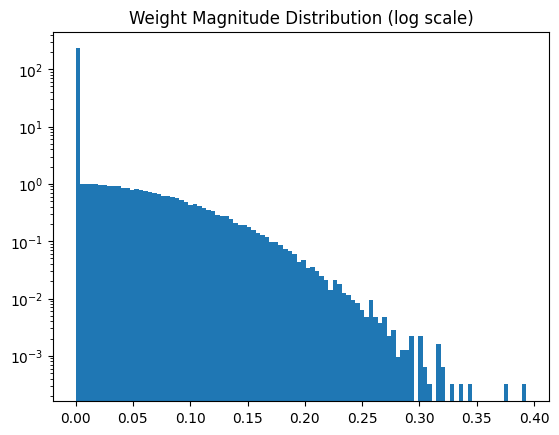

In [13]:
# plot weight values

weights = sparse_model_90.fc1.weight.detach().cpu().numpy().flatten()

plt.figure()
plt.hist(np.abs(weights), bins=100, density=True)
plt.yscale("log")
plt.title("Weight Magnitude Distribution (log scale)")
plt.show()

In [14]:
# Loss and optimizer
optimizer = optim.Adam(sparse_model_90.parameters(), lr=learning_rate)

In [15]:
epoch_grad_vars = []
epoch_grad_means = []
accuracy_history = []

for epoch in range(num_epochs):

    running_loss = 0.0
    grad_norms = []
    
    for x, y in train_loader:

        optimizer.zero_grad()
        output = sparse_model_90(x)
        loss = criterion(output, y)
        loss.backward()

        ## grad norm per epoch
        total_norm = 0
        for p in sparse_model_90.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item()**2
        total_norm = total_norm**0.5

        grad_norms.append(total_norm)

        optimizer.step()
        running_loss += loss.item()

        # Re-apply mask so pruned weights stay zero
        with torch.no_grad():
            for name, param in sparse_model_90.named_parameters():
                if name in masks:
                    param.mul_(masks[name])

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

    # per epoch accuracy
    acc = evaluate(sparse_model_90, test_loader)
    accuracy_history.append(acc)

    print("Epoch accuracy", acc)

    #per epoch gradient mean and variance
    epoch_grad_means.append(np.mean(grad_norms))
    epoch_grad_vars.append(np.var(grad_norms))




Epoch [1/10], Loss: 0.2125
Epoch [2/10], Loss: 0.0800
Epoch [3/10], Loss: 0.0642
Epoch [4/10], Loss: 0.0525
Epoch [5/10], Loss: 0.0510
Epoch [6/10], Loss: 0.0446
Epoch [7/10], Loss: 0.0416
Epoch [8/10], Loss: 0.0378
Epoch [9/10], Loss: 0.0333
Epoch [10/10], Loss: 0.0366


In [16]:
# Evaluation
sparse_model_90.eval()
correct = 0
total = 0

wrong_images = []
wrong_labels = []
wrong_preds = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = sparse_model_90(images)
        _, predicted = torch.max(outputs, 1)

        # incorrect predictions
        incorrect = predicted != labels
        wrong_images.extend(images[incorrect].cpu())
        wrong_labels.extend(labels[incorrect].cpu())
        wrong_preds.extend(predicted[incorrect].cpu())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 97.80%


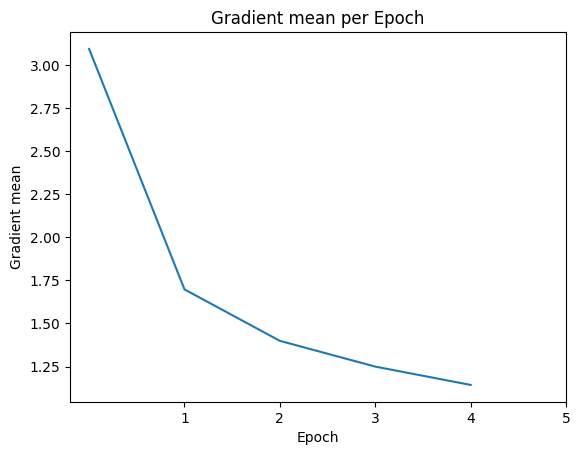

In [15]:
epochs = range(1, len(epoch_grad_vars) + 1)
plt.plot(epoch_grad_means)
plt.xlabel("Epoch")
plt.ylabel("Gradient mean")
plt.title("Gradient mean per Epoch")
plt.xticks(epochs)
plt.show()

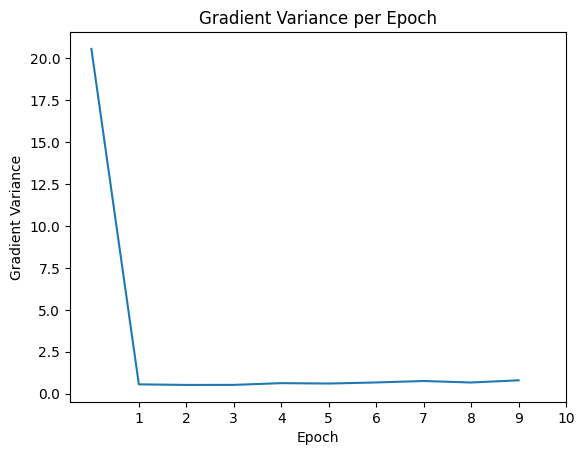

In [17]:
epochs = range(1, len(epoch_grad_vars) + 1)
plt.plot(epoch_grad_vars)
plt.xlabel("Epoch")
plt.ylabel("Gradient Variance")
plt.title("Gradient Variance per Epoch")
plt.xticks(epochs)
plt.show()

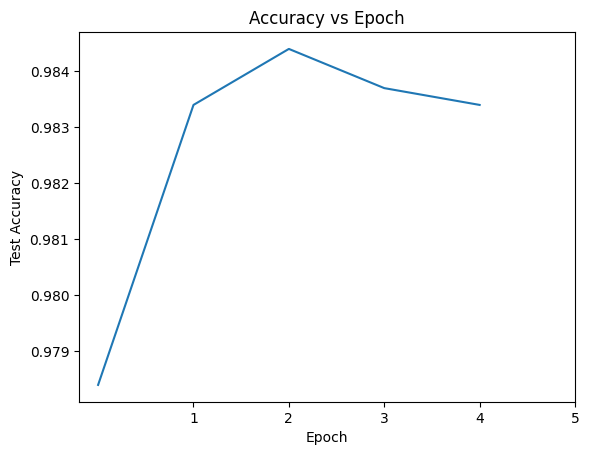

In [78]:
plt.figure()
epochs = range(1, len(epoch_grad_vars) + 1)
plt.plot(accuracy_history)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs Epoch")
plt.xticks(epochs)
plt.show()

In [19]:
total = 0
zeros = 0

for name, param in sparse_model_90.named_parameters():
    if name in masks:
        total += param.numel()
        zeros += (param == 0).sum().item()

print("Sparsity:", zeros / total)

Sparsity: 0.8999546169378325


## 99% sparsity

In [18]:
sparse_model_99 = SmallCNN()
# sparse_model_99 = DeeperCNN()


In [19]:
sparsity = 0.99

In [20]:
initialize_model(sparse_model_99, mode="he", df=5, sparsity=sparsity)
# masks = initialize_model_mask_first(sparse_model_99, mode="he", df=5, sparsity=sparsity)

In [21]:
masks = initialize_masks(sparse_model_99, sparsity)

In [22]:
with torch.no_grad():
    for name, param in sparse_model_99.named_parameters():
        if name in masks:
            # print("name", name)
            # print("param", param)
            # print(masks[name])
            param.mul_(masks[name])

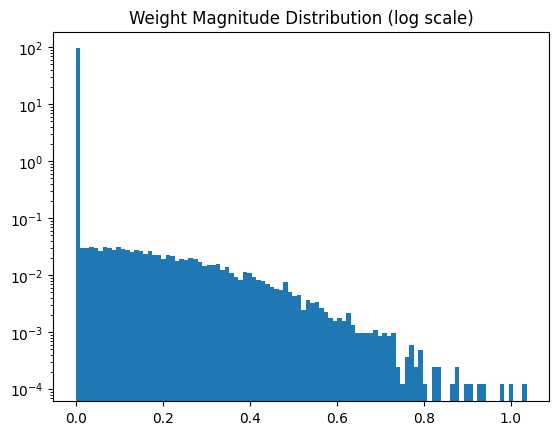

In [23]:
# plot weight values

weights = sparse_model_99.fc1.weight.detach().cpu().numpy().flatten()

plt.figure()
plt.hist(np.abs(weights), bins=100, density=True)
plt.yscale("log")
plt.title("Weight Magnitude Distribution (log scale)")
plt.show()

In [24]:
optimizer99 = optim.Adam(sparse_model_99.parameters(), lr=learning_rate)

In [25]:
total = 0
zeros = 0

for name, param in sparse_model_99.named_parameters():
    if name in masks:
        total += param.numel()
        zeros += (param == 0).sum().item()

print("Sparsity:", zeros / total)

Sparsity: 0.9901103754902342


In [26]:
epoch_grad_vars_99 = []
epoch_grad_means_99 = []
accuracy_history_99 = []

for epoch in range(num_epochs):

    running_loss = 0.0
    grad_norms = []
    
    for x, y in train_loader:

        optimizer99.zero_grad()
        output = sparse_model_99(x)
        loss = criterion(output, y)
        loss.backward()

        ## grad norm per epoch
        total_norm = 0
        for p in sparse_model_99.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item()**2
        total_norm = total_norm**0.5

        grad_norms.append(total_norm)


        optimizer99.step()
        running_loss += loss.item()

        #Re-apply mask so pruned weights stay zero
        with torch.no_grad():
            for name, param in sparse_model_99.named_parameters():
                if name in masks:
                    param.mul_(masks[name])

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

    # per epoch accuracy
    acc = evaluate(sparse_model_99, test_loader)
    print("Epoch accuracy", acc)
    accuracy_history_99.append(acc)

    #per epoch gradient mean and variance
    epoch_grad_means_99.append(np.mean(grad_norms))
    epoch_grad_vars_99.append(np.var(grad_norms))

Epoch [1/5], Loss: 2.0247
Epoch accuracy 0.3168
Epoch [2/5], Loss: 1.9147
Epoch accuracy 0.3363
Epoch [3/5], Loss: 1.9095
Epoch accuracy 0.3376
Epoch [4/5], Loss: 1.9064
Epoch accuracy 0.3408
Epoch [5/5], Loss: 1.9068
Epoch accuracy 0.3367


In [14]:
# Evaluation
sparse_model_99.eval()
correct = 0
total = 0

wrong_images = []
wrong_labels = []
wrong_preds = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = sparse_model_99(images)
        _, predicted = torch.max(outputs, 1)

        # incorrect predictions
        incorrect = predicted != labels
        wrong_images.extend(images[incorrect].cpu())
        wrong_labels.extend(labels[incorrect].cpu())
        wrong_preds.extend(predicted[incorrect].cpu())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")

Test Accuracy: 55.58%


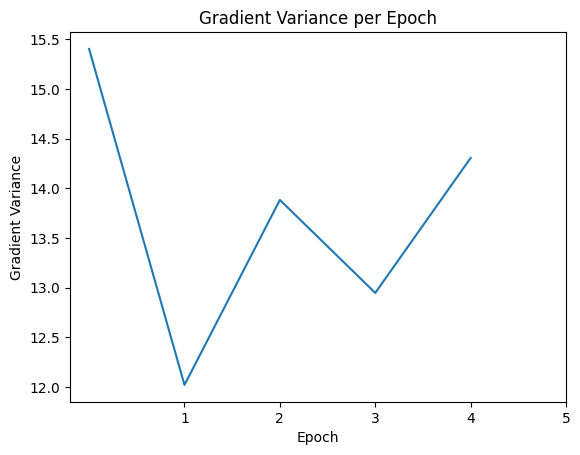

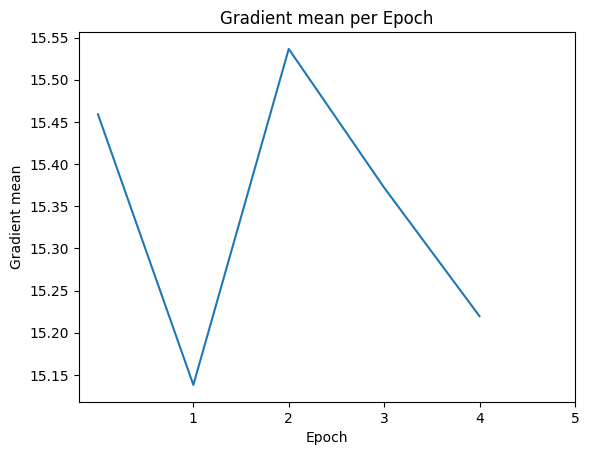

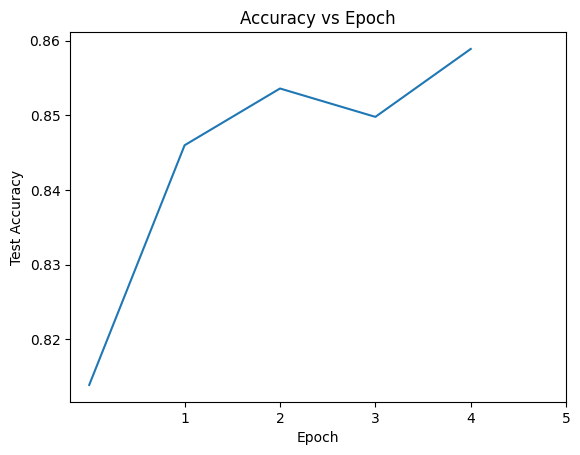

In [16]:
epochs = range(1, len(epoch_grad_vars_99) + 1)
plt.plot(epoch_grad_vars_99)
plt.xlabel("Epoch")
plt.ylabel("Gradient Variance")
plt.title("Gradient Variance per Epoch")
plt.xticks(epochs)
plt.show()

# epochs = range(1, len(epoch_grad_vars) + 1)
plt.plot(epoch_grad_means_99)
plt.xlabel("Epoch")
plt.ylabel("Gradient mean")
plt.title("Gradient mean per Epoch")
plt.xticks(epochs)
plt.show()

plt.figure()
# epochs = range(1, len(epoch_grad_vars) + 1)
plt.plot(accuracy_history_99)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs Epoch")
plt.xticks(epochs)
plt.show()

## 98% sparsity

In [8]:
sparse_model_98 = SmallCNN()
# sparse_model_98 = DeeperCNN()

In [9]:
sparsity = 0.98

In [ ]:
# masks = initialize_model_mask_first(sparse_model_98, mode="he", df=5, sparsity=sparsity)
initialize_model(sparse_model_98, mode="he", df=5, sparsity=sparsity)

In [31]:
masks = initialize_masks(sparse_model_98, sparsity)

In [ ]:
with torch.no_grad():
    for name, param in sparse_model_98.named_parameters():
        if name in masks:
            param.mul_(masks[name])

In [11]:
optimizer98 = optim.Adam(sparse_model_98.parameters(), lr=learning_rate)

In [12]:
epoch_grad_vars_98 = []
epoch_grad_means_98 = []
accuracy_history_98 = []

for epoch in range(num_epochs):

    running_loss = 0.0
    grad_norms = []
    
    for x, y in train_loader:

        optimizer98.zero_grad()
        output = sparse_model_98(x)
        loss = criterion(output, y)
        loss.backward()

        ## grad norm per epoch
        total_norm = 0
        for p in sparse_model_98.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item()**2
        total_norm = total_norm**0.5

        grad_norms.append(total_norm)


        optimizer98.step()
        running_loss += loss.item()

        # Re-apply mask so pruned weights stay zero
        with torch.no_grad():
            for name, param in sparse_model_98.named_parameters():
                if name in masks:
                    param.mul_(masks[name])

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

    # per epoch accuracy
    acc = evaluate(sparse_model_98, test_loader)
    print("Epoch accuracy", acc)
    accuracy_history_98.append(acc)

    #per epoch gradient mean and variance
    epoch_grad_means_98.append(np.mean(grad_norms))
    epoch_grad_vars_98.append(np.var(grad_norms))

Epoch [1/10], Loss: 0.6230
Epoch accuracy 0.8702
Epoch [2/10], Loss: 0.4358
Epoch accuracy 0.8777
Epoch [3/10], Loss: 0.4114
Epoch accuracy 0.8837
Epoch [4/10], Loss: 0.3951
Epoch accuracy 0.8933
Epoch [5/10], Loss: 0.3829
Epoch accuracy 0.8847
Epoch [6/10], Loss: 0.3723
Epoch accuracy 0.8945
Epoch [7/10], Loss: 0.3690
Epoch accuracy 0.8939
Epoch [8/10], Loss: 0.3565
Epoch accuracy 0.89
Epoch [9/10], Loss: 0.3588
Epoch accuracy 0.892
Epoch [10/10], Loss: 0.3536
Epoch accuracy 0.8967


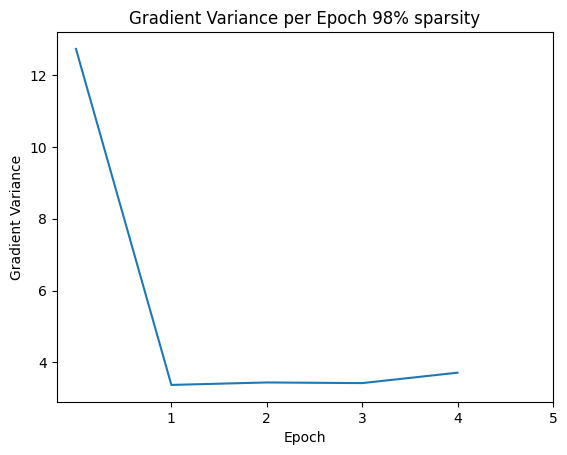

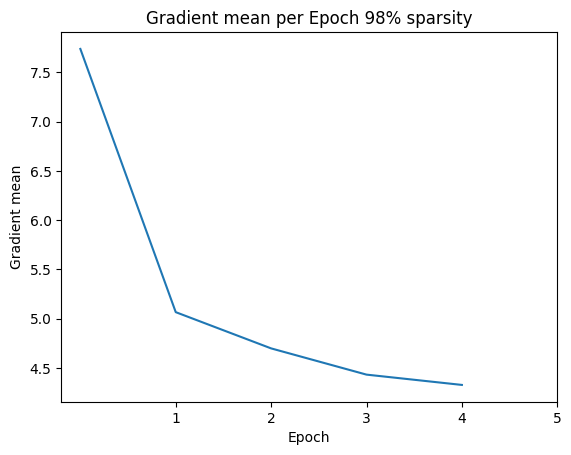

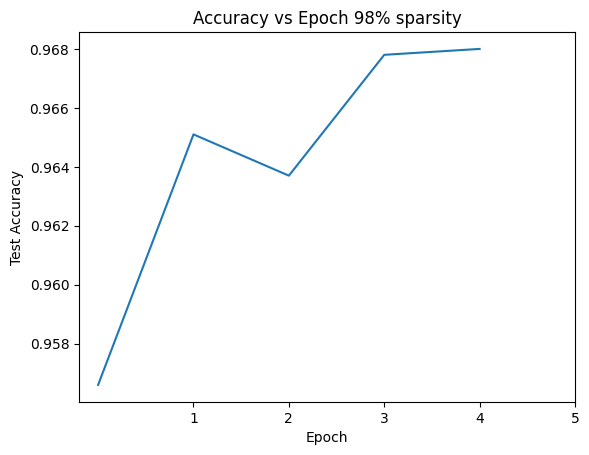

In [35]:
epochs = range(1, len(epoch_grad_vars_98) + 1)
plt.plot(epoch_grad_vars_98)
plt.xlabel("Epoch")
plt.ylabel("Gradient Variance")
plt.title("Gradient Variance per Epoch 98% sparsity")
plt.xticks(epochs)
plt.show()

# epochs = range(1, len(epoch_grad_vars) + 1)
plt.plot(epoch_grad_means_98)
plt.xlabel("Epoch")
plt.ylabel("Gradient mean")
plt.title("Gradient mean per Epoch 98% sparsity")
plt.xticks(epochs)
plt.show()

plt.figure()
# epochs = range(1, len(epoch_grad_vars) + 1)
plt.plot(accuracy_history_98)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs Epoch 98% sparsity")
plt.xticks(epochs)
plt.show()